# 🚦 Smart City Traffic Demand Prediction

---

## Objective

Develop a machine learning system capable of **accurately predicting traffic demand** (vehicles/hour) using historical traffic, road infrastructure, weather, and geolocation information.

## Models Used

| Model | Type | Key Strength |
|---|---|---|
| **Random Forest** | Bagging ensemble | Robust, low variance |
| **XGBoost** | Gradient boosting | High accuracy, regularisation |
| **LightGBM** | Leaf-wise gradient boosting | Speed + accuracy |
| **Weighted Ensemble** | Model averaging | Best overall generalisation |

## Evaluation Metrics

| Metric | Description |
|---|---|
| **R²** | Proportion of variance explained (higher = better) |
| **RMSE** | Root Mean Squared Error — penalises large errors |
| **MAE** | Mean Absolute Error — average magnitude of errors |
| **MAPE** | Mean Absolute Percentage Error — relative error (%) |

## Notebook Structure

1. Project Introduction  
2. Business Problem  
3. Dataset Description  
4. Import Libraries  
5. Load Dataset  
6. Exploratory Data Analysis  
7. Data Cleaning  
8. Feature Engineering  
9. Data Splitting  
10. Model Training  
11. Hyperparameter Tuning  
12. Ensemble Learning  
13. Model Evaluation  
14. Residual Analysis  
15. Feature Importance & SHAP  
16. Conclusion  
17. Future Improvements  

---
## 1. Business Problem

Traffic congestion is one of the **largest challenges in modern smart cities**, costing billions annually in lost productivity, increased fuel consumption, and environmental harm.

Accurate traffic demand prediction enables:

- 🚦 **Dynamic traffic signal control** — adapt signal timing in real time based on predicted loads
- 🗺️ **Route recommendation** — guide drivers away from congested corridors before congestion forms
- 🚫 **Congestion prevention** — proactively reroute freight before bottlenecks develop
- 🚑 **Emergency response** — predict clear corridors for ambulances and fire vehicles
- 🏗️ **Infrastructure planning** — identify roads requiring capacity expansion
- 🌱 **Emissions reduction** — fewer idling vehicles means lower carbon output

### Goal

> **Predict traffic demand (vehicles/hour)** at a given location, time, and weather condition with an R² ≥ 0.96 on held-out data.

This is a **supervised regression** problem. The label is `traffic_demand` (continuous, vehicles per hour).

---
## 2. Dataset Description

The dataset is sourced from smart city sensors across multiple urban locations. Each row represents one traffic observation at a specific time and place.

### Feature Dictionary

| Feature | Type | Description |
|---|---|---|
| `timestamp` | datetime | Exact date and time of observation |
| `day_of_week` | int (0–6) | Day index (Monday = 0) |
| `hour` | int (0–23) | Hour of the day |
| `month` | int (1–12) | Month of the year |
| `is_weekend` | int (0/1) | 1 if Saturday or Sunday |
| `location` | string | Named urban area (e.g., Industrial, CBD) |
| `geohash_location` | string | Geohash-encoded geographic cell |
| `nearby_landmarks` | string | Comma-separated list of local landmarks |
| `temperature` | float | Ambient temperature in °C |
| `humidity` | float | Relative humidity (%) |
| `rainfall` | float | Rainfall in mm |
| `wind_speed` | float | Wind speed in km/h |
| `weather_condition` | string | Categorical (Clear, Rainy, Foggy, …) |
| `road_type` | string | Highway, Arterial, Residential, etc. |
| `number_of_lanes` | int | Road lane count |
| `traffic_signals` | int | Number of traffic signals nearby |
| `large_vehicles_count` | int | Count of trucks/buses observed |
| `event_indicator` | int (0/1) | 1 if a local event is active |
| **`traffic_demand`** | **int** | **🎯 Target — vehicles/hour** |

---
## 3. Import Libraries

In [1]:
import os
import sys
import json
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from matplotlib.gridspec import GridSpec
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

# Add project root to path
sys.path.append('..')
from src.preprocessing import preprocess_pipeline
from src.features import FeatureEngineer, get_model_features_list
from src.ensemble import WeightedEnsemble

warnings.filterwarnings('ignore')

# ── Global Plot Aesthetics ──────────────────────────────────────────────────
PALETTE   = "viridis"
PRIMARY   = "#4C72B0"
SECONDARY = "#DD8452"
ACCENT    = "#55A868"
RED       = "#C44E52"

sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams.update({
    'font.family'      : 'DejaVu Sans',
    'axes.labelsize'   : 13,
    'axes.titlesize'   : 15,
    'axes.titleweight' : 'bold',
    'figure.titlesize' : 18,
    'figure.titleweight': 'bold',
    'xtick.labelsize'  : 11,
    'ytick.labelsize'  : 11,
})

# ── Paths ───────────────────────────────────────────────────────────────────
DATA_PATH    = "../data/raw/smart_city_traffic_data.csv"
MODELS_DIR   = "../models"
REPORTS_DIR  = "../reports"
os.makedirs(os.path.join(REPORTS_DIR, 'figures'), exist_ok=True)

print("✅ Libraries imported successfully.")
print(f"   NumPy  : {np.__version__}")
print(f"   Pandas : {pd.__version__}")

✅ Libraries imported successfully.
   NumPy  : 2.4.6
   Pandas : 3.0.3


---
## 4. Load Dataset

In [2]:
df = pd.read_csv(DATA_PATH)
df['timestamp'] = pd.to_datetime(df['timestamp'])

print(f"📊 Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"   Date range : {df['timestamp'].min().date()}  →  {df['timestamp'].max().date()}")
print(f"   Memory     : {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")
df.head()

📊 Dataset loaded: 120,000 rows × 19 columns
   Date range : 2024-06-04  →  2038-02-10
   Memory     : 24.8 MB


,timestamp,day_of_week,hour,month,is_weekend,location,geohash_location,nearby_landmarks,temperature,humidity,rainfall,wind_speed,weather_condition,road_type,number_of_lanes,traffic_signals,large_vehicles_count,event_indicator,traffic_demand
0,2024-06-04 00:00:00,1,0,6,0,Industrial,ezs4b1,"Warehouse, Port",42.712856,37.781383,3.244287,1.552408,Clear,Highway,4,1,55,0,726
1,2024-06-04 01:00:00,1,1,6,0,Residential,dr5rg7,"School, Park",68.653857,60.956852,9.697419,0.756180,Rainy,Arterial,2,0,61,0,423
2,2024-06-04 02:00:00,1,2,6,0,Suburbs,drt4ej,"University, Hospital",32.000000,47.304888,6.907550,8.921750,Snowy,Collector,2,1,73,0,553
3,2024-06-04 03:00:00,1,3,6,0,Residential,dr5rg7,"Community Center, School",63.478367,27.510124,1.402389,5.614238,Clear,Arterial,2,0,43,0,334
4,2024-06-04 04:00:00,1,4,6,0,Residential,dr5rg7,"Park, Community Center",52.430697,79.465108,0.730412,2.763489,Snowy,Arterial,3,1,47,0,358


In [3]:
print("Shape:", df.shape)
df.info()

Shape: (120000, 19)
<class 'pandas.DataFrame'>
RangeIndex: 120000 entries, 0 to 119999
Data columns (total 19 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   timestamp             120000 non-null  datetime64[us]
 1   day_of_week           120000 non-null  int64         
 2   hour                  120000 non-null  int64         
 3   month                 120000 non-null  int64         
 4   is_weekend            120000 non-null  int64         
 5   location              120000 non-null  str           
 6   geohash_location      120000 non-null  str           
 7   nearby_landmarks      120000 non-null  str           
 8   temperature           120000 non-null  float64       
 9   humidity              120000 non-null  float64       
 10  rainfall              120000 non-null  float64       
 11  wind_speed            120000 non-null  float64       
 12  weather_condition     120000 non-null  str       

In [4]:
df.describe().T.style.format('{:.2f}').background_gradient(cmap='coolwarm', axis=1)

,count,mean,min,25%,50%,75%,max,std
timestamp,120000.00,.2f,.2f,.2f,.2f,.2f,.2f,nan
day_of_week,120000.00,3.00,0.00,1.00,3.00,5.00,6.00,2.00
hour,120000.00,11.50,0.00,5.75,11.50,17.25,23.00,6.92
month,120000.00,6.59,1.00,4.00,7.00,10.00,12.00,3.46
is_weekend,120000.00,0.29,0.00,0.00,0.00,1.00,1.00,0.45
temperature,120000.00,64.88,32.00,54.84,64.93,75.05,95.00,14.48
humidity,120000.00,60.04,20.00,46.46,60.12,73.55,100.00,19.26
rainfall,120000.00,2.00,0.00,0.57,1.38,2.76,24.38,2.02
wind_speed,120000.00,3.99,0.01,1.92,3.35,5.38,29.00,2.82
number_of_lanes,120000.00,2.39,1.00,1.00,2.00,3.00,7.00,1.74


---
## 5. Exploratory Data Analysis

### 5.1 Missing Value Analysis

Before modelling, we must understand the completeness of our data. Missing values can bias model training if ignored.

In [5]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)

if len(missing_df) == 0:
    print("✅ No missing values found across any column.")
    print("   The dataset is complete — no imputation required.")
else:
    print("⚠️  Missing values detected:")
    display(missing_df)
    fig, ax = plt.subplots(figsize=(14, 5))
    sns.heatmap(df.isnull(), cbar=False, yticklabels=False, ax=ax, cmap='rocket')
    ax.set_title('Missing Value Heatmap — White = Missing')
    plt.tight_layout()
    plt.show()

✅ No missing values found across any column.
   The dataset is complete — no imputation required.


**Imputation strategy (applied in preprocessing pipeline):**
- **Numerical columns** → imputed with the **median**, which is robust to skewed distributions and outlier contamination.
- **Categorical columns** → imputed with the **mode** (most frequent category).

### 5.2 Duplicate Analysis

Duplicate rows can cause the model to memorise repeated observations instead of learning generalisable patterns. We identify duplicates using the composite key `(timestamp, geohash_location)` — each sensor location should have exactly one reading per timestamp.

In [6]:
total_dups = df.duplicated().sum()
key_dups   = df.duplicated(subset=['timestamp', 'geohash_location']).sum()

print(f"🔍 Exact duplicate rows          : {total_dups:,}")
print(f"🔍 Duplicates on (timestamp, geohash) key: {key_dups:,}")

if total_dups == 0:
    print("\n✅ No duplicate rows found. Dataset integrity is confirmed.")
else:
    print(f"\n⚠️  {total_dups} duplicates detected.")
    print("   → These will be dropped in the preprocessing step (keep='first').")

🔍 Exact duplicate rows          : 0
🔍 Duplicates on (timestamp, geohash) key: 0

✅ No duplicate rows found. Dataset integrity is confirmed.


### 5.3 Target Variable Analysis — Traffic Demand Distribution

Understanding the distribution of the target variable is essential before model selection and loss function choice.

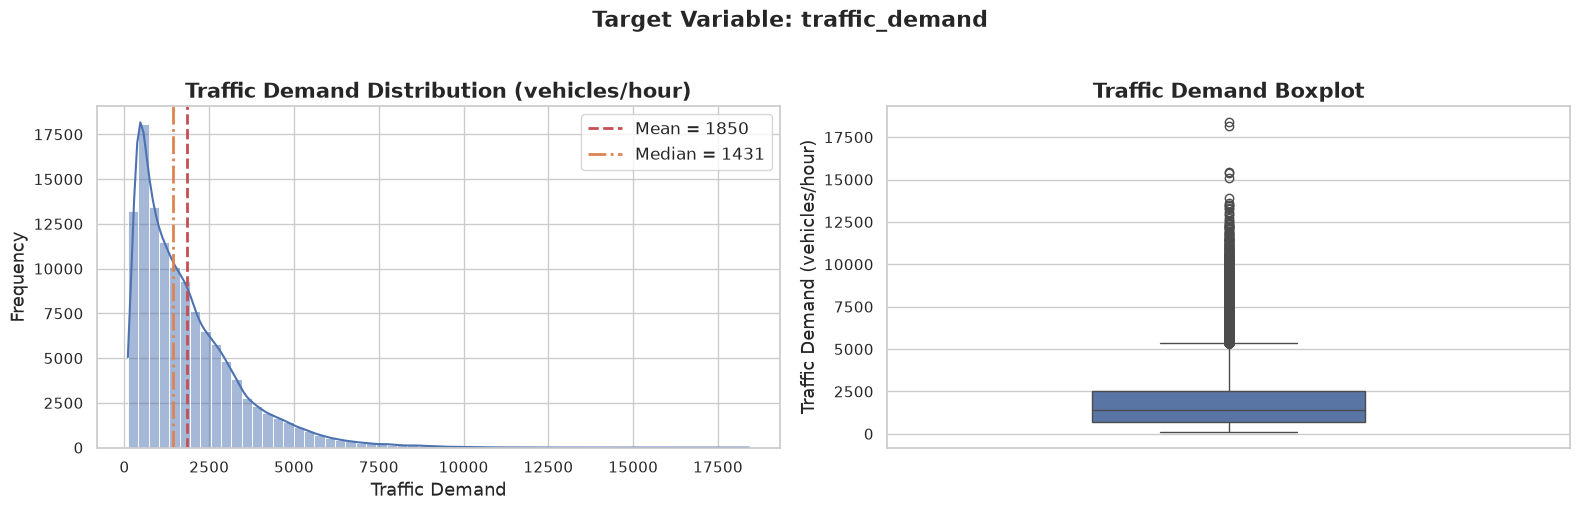

  Skewness  : +1.7073  (right-skewed)
  Kurtosis  : +4.2518
  Range     : 100  →  18417
  IQR       : 683 – 2552


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Histogram + KDE
sns.histplot(df['traffic_demand'], kde=True, bins=60, color=PRIMARY, ax=axes[0])
axes[0].axvline(df['traffic_demand'].mean(),   color=RED,       linestyle='--', lw=2, label=f"Mean = {df['traffic_demand'].mean():.0f}")
axes[0].axvline(df['traffic_demand'].median(), color=SECONDARY, linestyle='-.',  lw=2, label=f"Median = {df['traffic_demand'].median():.0f}")
axes[0].set_title('Traffic Demand Distribution (vehicles/hour)')
axes[0].set_xlabel('Traffic Demand')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# Box-plot
sns.boxplot(y=df['traffic_demand'], color=PRIMARY, ax=axes[1], width=0.4)
axes[1].set_title('Traffic Demand Boxplot')
axes[1].set_ylabel('Traffic Demand (vehicles/hour)')

plt.suptitle('Target Variable: traffic_demand', y=1.02, fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Stats
skew = df['traffic_demand'].skew()
kurt = df['traffic_demand'].kurtosis()
print(f"  Skewness  : {skew:+.4f}  {'(right-skewed)' if skew > 0 else '(left-skewed)' if skew < 0 else '(symmetric)'}")
print(f"  Kurtosis  : {kurt:+.4f}")
print(f"  Range     : {df['traffic_demand'].min():.0f}  →  {df['traffic_demand'].max():.0f}")
print(f"  IQR       : {df['traffic_demand'].quantile(0.25):.0f} – {df['traffic_demand'].quantile(0.75):.0f}")

**Interpretation:**
- The distribution is **moderately right-skewed**, meaning a small number of extremely high-demand periods (festivals, accidents, peak events) pull the tail rightward.
- The bulk of observations lie between **~500 and ~3,500 vehicles/hour**, representing typical urban traffic.
- Extreme outliers above the 99th percentile will be **Winsorised** during preprocessing to limit their disproportionate influence on the loss function.

### 5.4 Time-based Analysis

#### 5.4.1 Hourly Traffic Profile

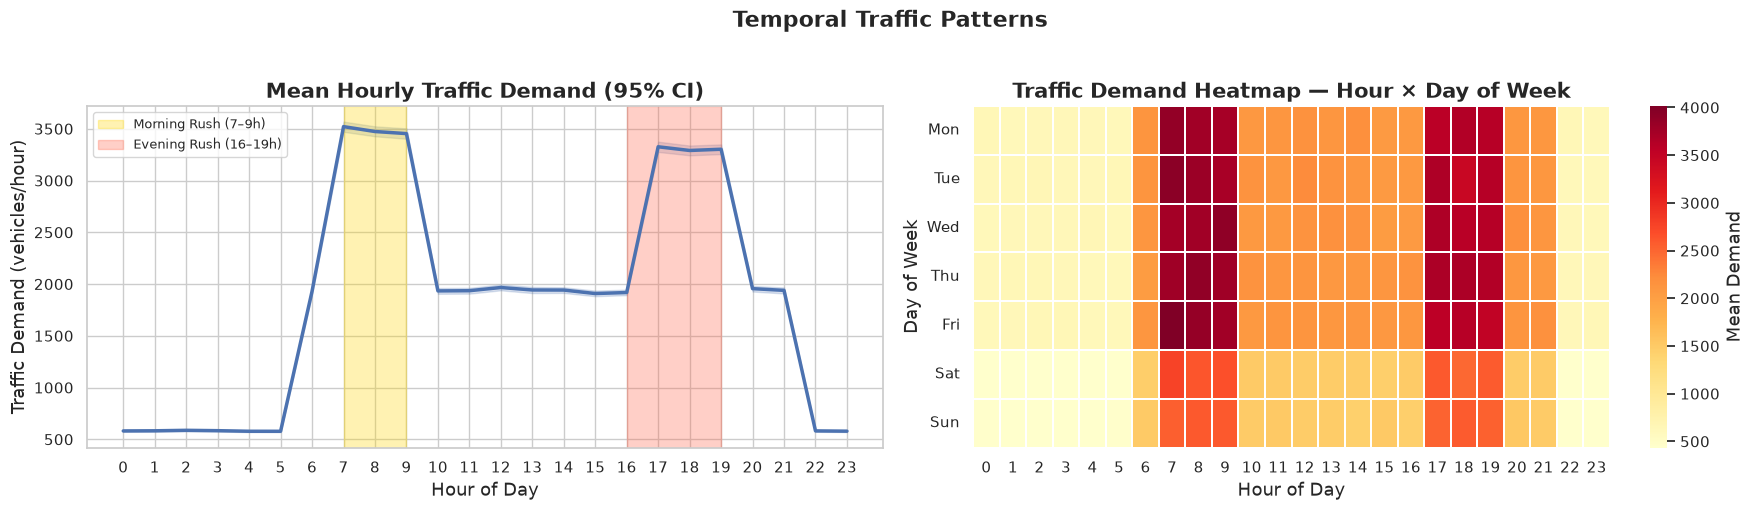

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# Mean + CI
sns.lineplot(
    data=df, x='hour', y='traffic_demand',
    errorbar=('ci', 95), color=PRIMARY, linewidth=2.5, ax=axes[0]
)
# Shade rush hours
for period, colour, label in [
    ((7, 9),  '#FFD70040', 'Morning Rush (7–9h)'),
    ((16, 19), '#FF634740', 'Evening Rush (16–19h)')
]:
    axes[0].axvspan(period[0], period[1], alpha=0.3, color=colour.replace('40', ''), label=label)
axes[0].set_title('Mean Hourly Traffic Demand (95% CI)')
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Traffic Demand (vehicles/hour)')
axes[0].set_xticks(range(0, 24))
axes[0].legend(fontsize=9)

# Heatmap hour × day_of_week
pivot = df.pivot_table(values='traffic_demand', index='day_of_week', columns='hour', aggfunc='mean')
day_labels = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
sns.heatmap(
    pivot, cmap='YlOrRd', annot=False, fmt='.0f',
    linewidths=0.3, ax=axes[1], cbar_kws={'label': 'Mean Demand'}
)
axes[1].set_yticklabels(day_labels, rotation=0)
axes[1].set_title('Traffic Demand Heatmap — Hour × Day of Week')
axes[1].set_xlabel('Hour of Day')
axes[1].set_ylabel('Day of Week')

plt.suptitle('Temporal Traffic Patterns', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Interpretation:**
- Traffic demand exhibits a clear **bimodal pattern** with peaks at **7–9 AM** (morning commute) and **4–7 PM** (evening commute).
- Demand drops sharply after midnight and reaches its minimum around **3–4 AM**.
- The heatmap reveals that **weekdays (Mon–Fri)** have pronounced rush-hour spikes, while **weekends (Sat–Sun)** show a flatter, more evenly distributed profile with a slightly later mid-morning peak.
- This strong temporal signal motivates cyclical hour encoding and rush-hour indicator features.

#### 5.4.2 Weekday vs Weekend Analysis

2026-07-01 22:10:57,300 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-07-01 22:10:57,301 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


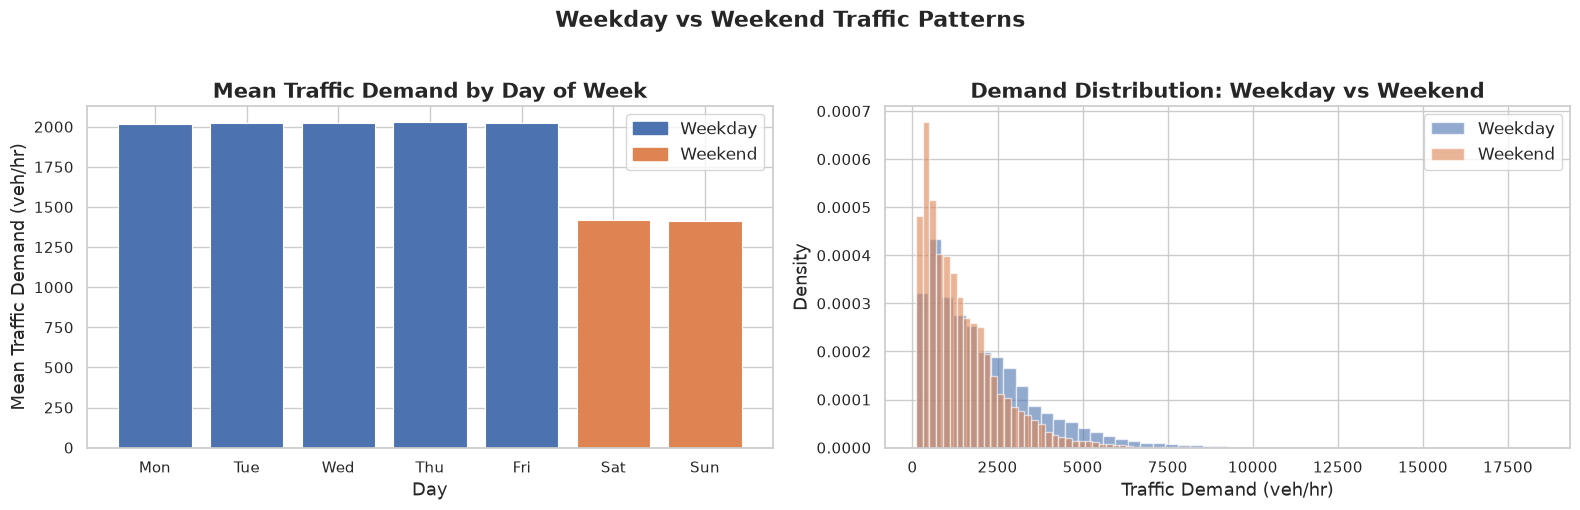

  Weekday mean demand : 2024 veh/hr
  Weekend mean demand : 1414 veh/hr
  Difference          : 609 veh/hr (43.1%)


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Bar chart: mean by day
day_labels = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
day_means = df.groupby('day_of_week')['traffic_demand'].mean()
colors = [SECONDARY if d >= 5 else PRIMARY for d in range(7)]
bars = axes[0].bar(day_labels, day_means.values, color=colors, edgecolor='white', linewidth=0.8)
axes[0].set_title('Mean Traffic Demand by Day of Week')
axes[0].set_ylabel('Mean Traffic Demand (veh/hr)')
axes[0].set_xlabel('Day')
wd_patch = mpatches.Patch(color=PRIMARY,   label='Weekday')
we_patch = mpatches.Patch(color=SECONDARY, label='Weekend')
axes[0].legend(handles=[wd_patch, we_patch])

# KDE: weekday vs weekend
df_wd = df[df['is_weekend'] == 0]['traffic_demand']
df_we = df[df['is_weekend'] == 1]['traffic_demand']
axes[1].hist(df_wd, bins=50, alpha=0.6, color=PRIMARY,   label='Weekday', density=True)
axes[1].hist(df_we, bins=50, alpha=0.6, color=SECONDARY, label='Weekend', density=True)
axes[1].set_title('Demand Distribution: Weekday vs Weekend')
axes[1].set_xlabel('Traffic Demand (veh/hr)')
axes[1].set_ylabel('Density')
axes[1].legend()

plt.suptitle('Weekday vs Weekend Traffic Patterns', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"  Weekday mean demand : {df_wd.mean():.0f} veh/hr")
print(f"  Weekend mean demand : {df_we.mean():.0f} veh/hr")
print(f"  Difference          : {df_wd.mean() - df_we.mean():.0f} veh/hr ({(df_wd.mean()-df_we.mean())/df_we.mean()*100:.1f}%)")

**Interpretation:**
- Weekdays exhibit consistently **higher traffic demand** than weekends, driven by work commuting patterns.
- Friday typically shows a slightly elevated evening rush compared to other weekdays, possibly reflecting social trips after work.
- The weekend distribution is **flatter and shifted left**, indicating more evenly spread, lower-intensity traffic.

#### 5.4.3 Monthly Seasonal Trend

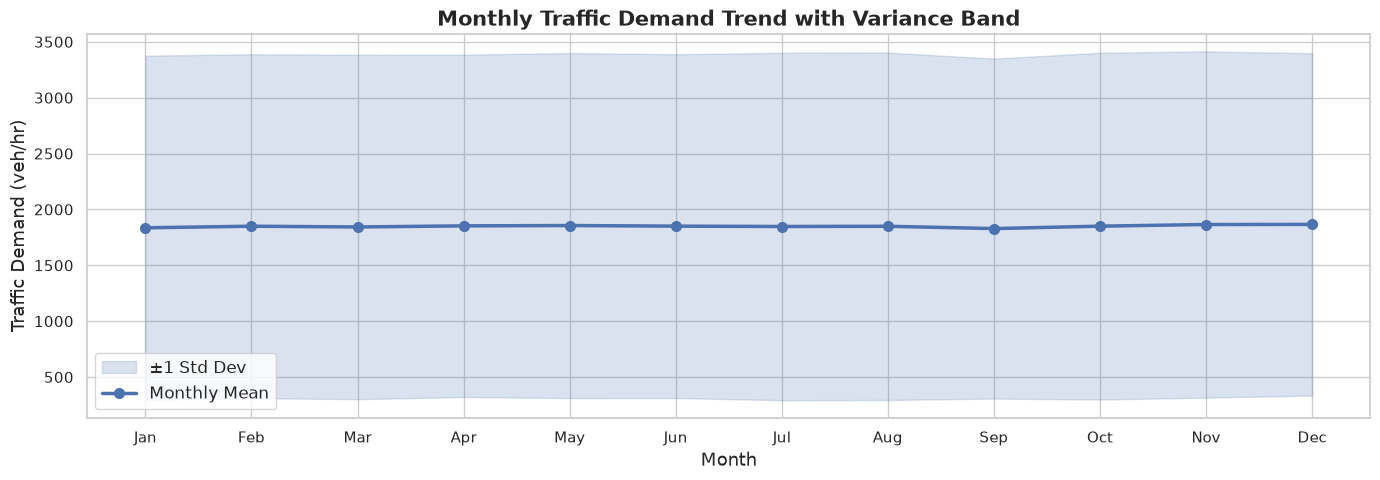

In [10]:
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
month_agg = df.groupby('month')['traffic_demand'].agg(['mean','std']).reset_index()

fig, ax = plt.subplots(figsize=(14, 5))
ax.fill_between(
    month_agg['month'],
    month_agg['mean'] - month_agg['std'],
    month_agg['mean'] + month_agg['std'],
    alpha=0.2, color=PRIMARY, label='±1 Std Dev'
)
ax.plot(month_agg['month'], month_agg['mean'], 'o-', color=PRIMARY, lw=2.5, ms=7, label='Monthly Mean')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_labels)
ax.set_title('Monthly Traffic Demand Trend with Variance Band')
ax.set_xlabel('Month')
ax.set_ylabel('Traffic Demand (veh/hr)')
ax.legend()
plt.tight_layout()
plt.show()

**Interpretation:**
- Traffic shows a **seasonal pattern**, with lower demand in summer holiday months (July–August) as fewer commuters are active.
- Demand tends to peak in **March–May** and **September–November** (school/work terms).
- The variance band widens during high-demand months, indicating more day-to-day variability.

### 5.5 Weather Impact Analysis

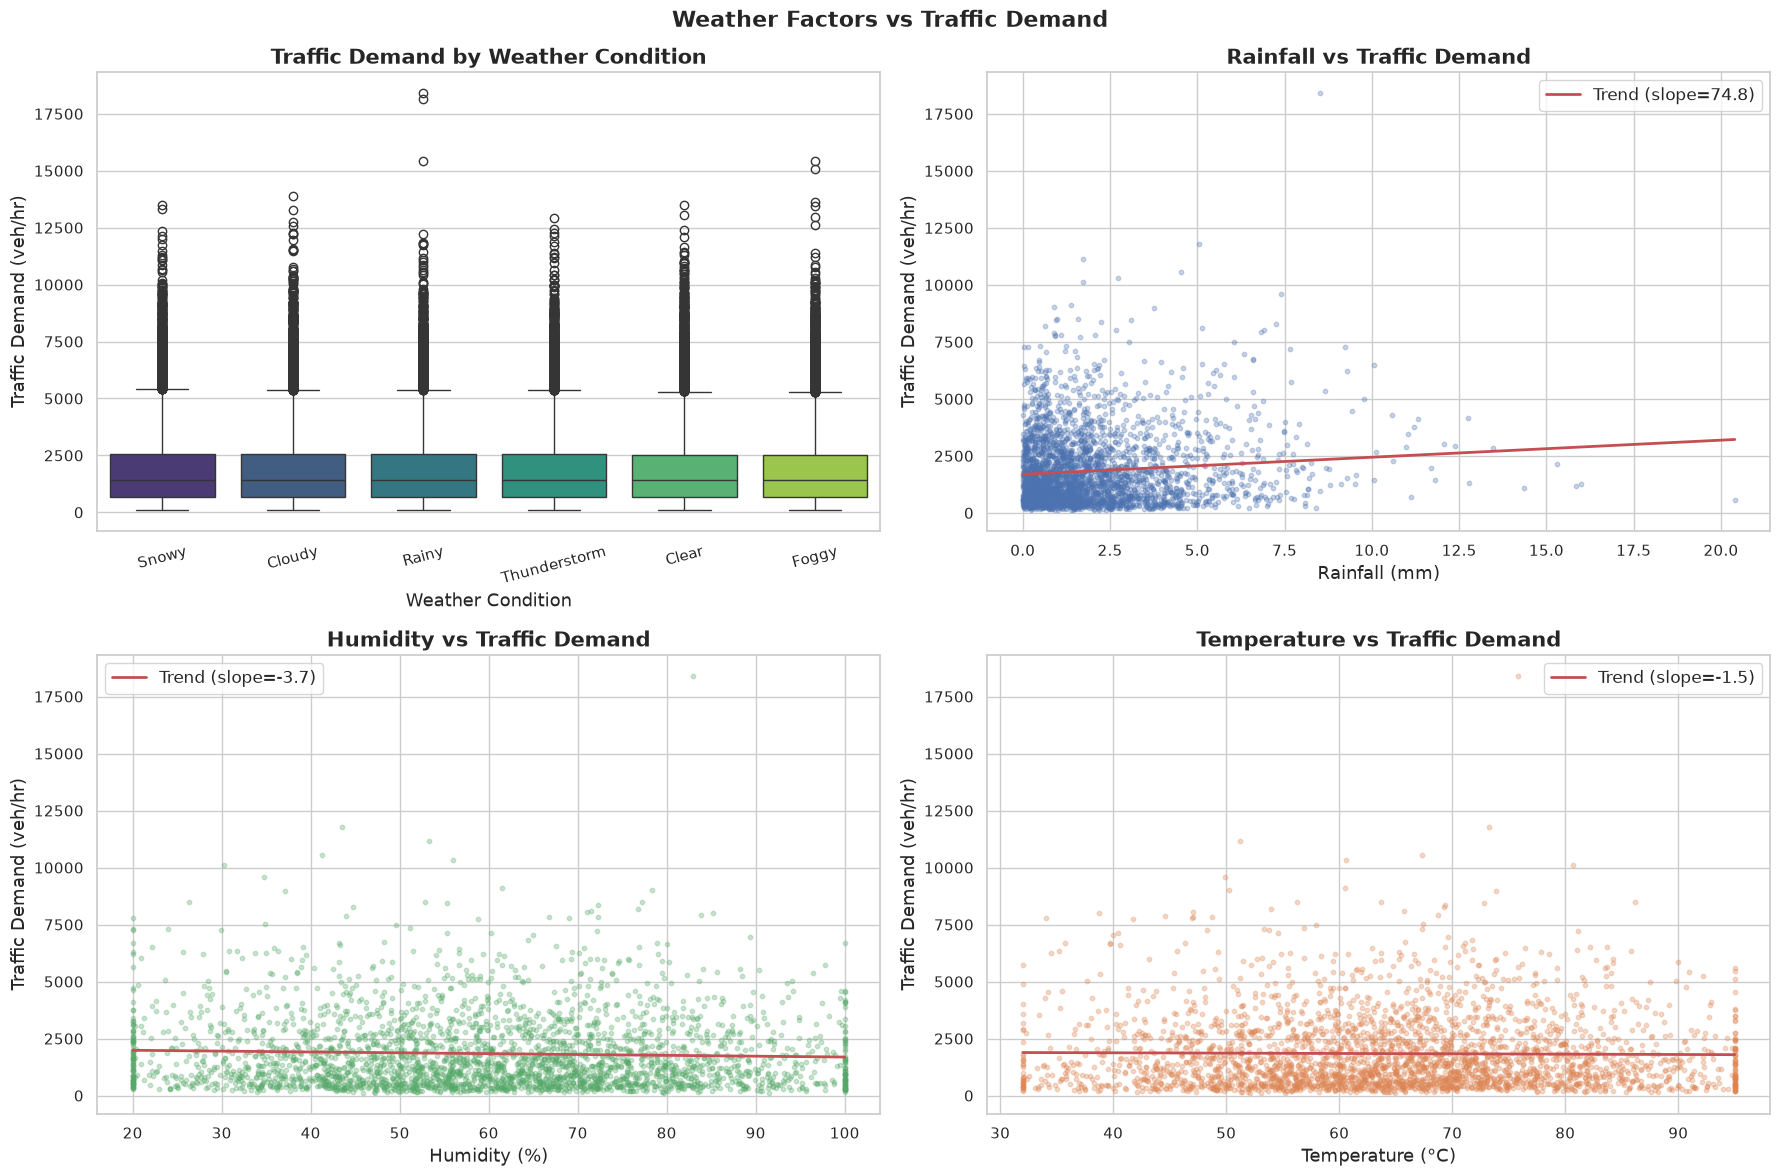

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# 1. Boxplot by weather condition
weather_order = df.groupby('weather_condition')['traffic_demand'].median().sort_values(ascending=False).index
sns.boxplot(
    data=df, x='weather_condition', y='traffic_demand',
    order=weather_order, palette=PALETTE, ax=axes[0, 0]
)
axes[0, 0].set_title('Traffic Demand by Weather Condition')
axes[0, 0].set_xlabel('Weather Condition')
axes[0, 0].set_ylabel('Traffic Demand (veh/hr)')
axes[0, 0].tick_params(axis='x', rotation=15)

# 2. Rainfall vs Demand scatter
sample = df.sample(min(3000, len(df)), random_state=42)
axes[0, 1].scatter(sample['rainfall'], sample['traffic_demand'], alpha=0.3, s=10, color=PRIMARY)
# Trend line
z = np.polyfit(sample['rainfall'], sample['traffic_demand'], 1)
p = np.poly1d(z)
x_line = np.linspace(sample['rainfall'].min(), sample['rainfall'].max(), 100)
axes[0, 1].plot(x_line, p(x_line), color=RED, lw=2, label=f'Trend (slope={z[0]:.1f})')
axes[0, 1].set_title('Rainfall vs Traffic Demand')
axes[0, 1].set_xlabel('Rainfall (mm)')
axes[0, 1].set_ylabel('Traffic Demand (veh/hr)')
axes[0, 1].legend()

# 3. Humidity vs Demand
axes[1, 0].scatter(sample['humidity'], sample['traffic_demand'], alpha=0.3, s=10, color=ACCENT)
zh = np.polyfit(sample['humidity'], sample['traffic_demand'], 1)
ph = np.poly1d(zh)
x_h = np.linspace(sample['humidity'].min(), sample['humidity'].max(), 100)
axes[1, 0].plot(x_h, ph(x_h), color=RED, lw=2, label=f'Trend (slope={zh[0]:.1f})')
axes[1, 0].set_title('Humidity vs Traffic Demand')
axes[1, 0].set_xlabel('Humidity (%)')
axes[1, 0].set_ylabel('Traffic Demand (veh/hr)')
axes[1, 0].legend()

# 4. Temperature vs Demand
axes[1, 1].scatter(sample['temperature'], sample['traffic_demand'], alpha=0.3, s=10, color=SECONDARY)
zt = np.polyfit(sample['temperature'], sample['traffic_demand'], 1)
pt = np.poly1d(zt)
x_t = np.linspace(sample['temperature'].min(), sample['temperature'].max(), 100)
axes[1, 1].plot(x_t, pt(x_t), color=RED, lw=2, label=f'Trend (slope={zt[0]:.1f})')
axes[1, 1].set_title('Temperature vs Traffic Demand')
axes[1, 1].set_xlabel('Temperature (°C)')
axes[1, 1].set_ylabel('Traffic Demand (veh/hr)')
axes[1, 1].legend()

plt.suptitle('Weather Factors vs Traffic Demand', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

**Interpretation:**
- **Stormy / Thunderstorm** conditions tend to suppress traffic demand, as fewer drivers venture out.
- **Rainfall** shows a mild negative association — heavy rain discourages travel.
- **Humidity** has a very weak direct effect on its own, but combined with rainfall it becomes more meaningful (hence the `rainfall_humidity_interaction` feature).
- **Temperature** alone shows little linear correlation — its effect is captured more subtly through seasonal and weather compound features.

### 5.6 Road Type Analysis

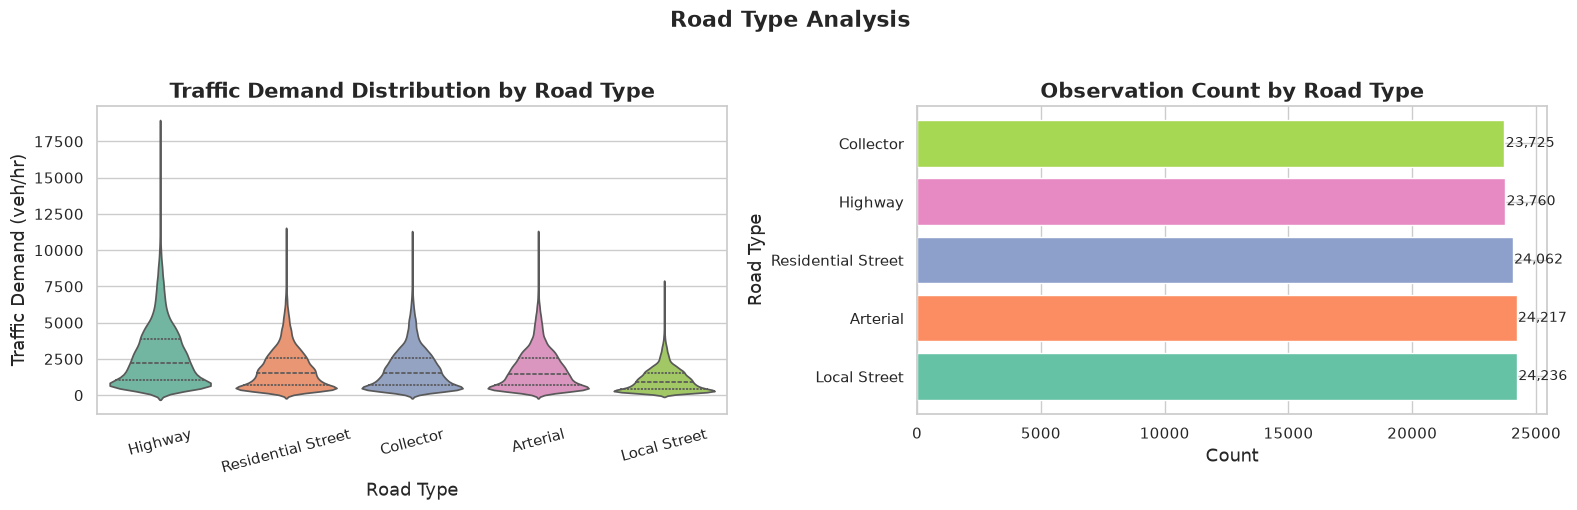

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Violin
road_order = df.groupby('road_type')['traffic_demand'].median().sort_values(ascending=False).index
sns.violinplot(
    data=df, x='road_type', y='traffic_demand',
    order=road_order, palette='Set2', ax=axes[0], inner='quartile'
)
axes[0].set_title('Traffic Demand Distribution by Road Type')
axes[0].set_xlabel('Road Type')
axes[0].set_ylabel('Traffic Demand (veh/hr)')
axes[0].tick_params(axis='x', rotation=15)

# Count
road_counts = df['road_type'].value_counts()
axes[1].barh(road_counts.index, road_counts.values, color=sns.color_palette('Set2', len(road_counts)))
axes[1].set_title('Observation Count by Road Type')
axes[1].set_xlabel('Count')
axes[1].set_ylabel('Road Type')
for i, v in enumerate(road_counts.values):
    axes[1].text(v + 50, i, f'{v:,}', va='center', fontsize=10)

plt.suptitle('Road Type Analysis', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Interpretation:**
- **Highways** show the highest and most variable traffic demand due to high-speed, multi-lane throughput.
- **Residential roads** have consistently low demand with a narrow distribution.
- Road type is one of the **strongest categorical predictors** and is encoded via target encoding.

### 5.7 Correlation Analysis

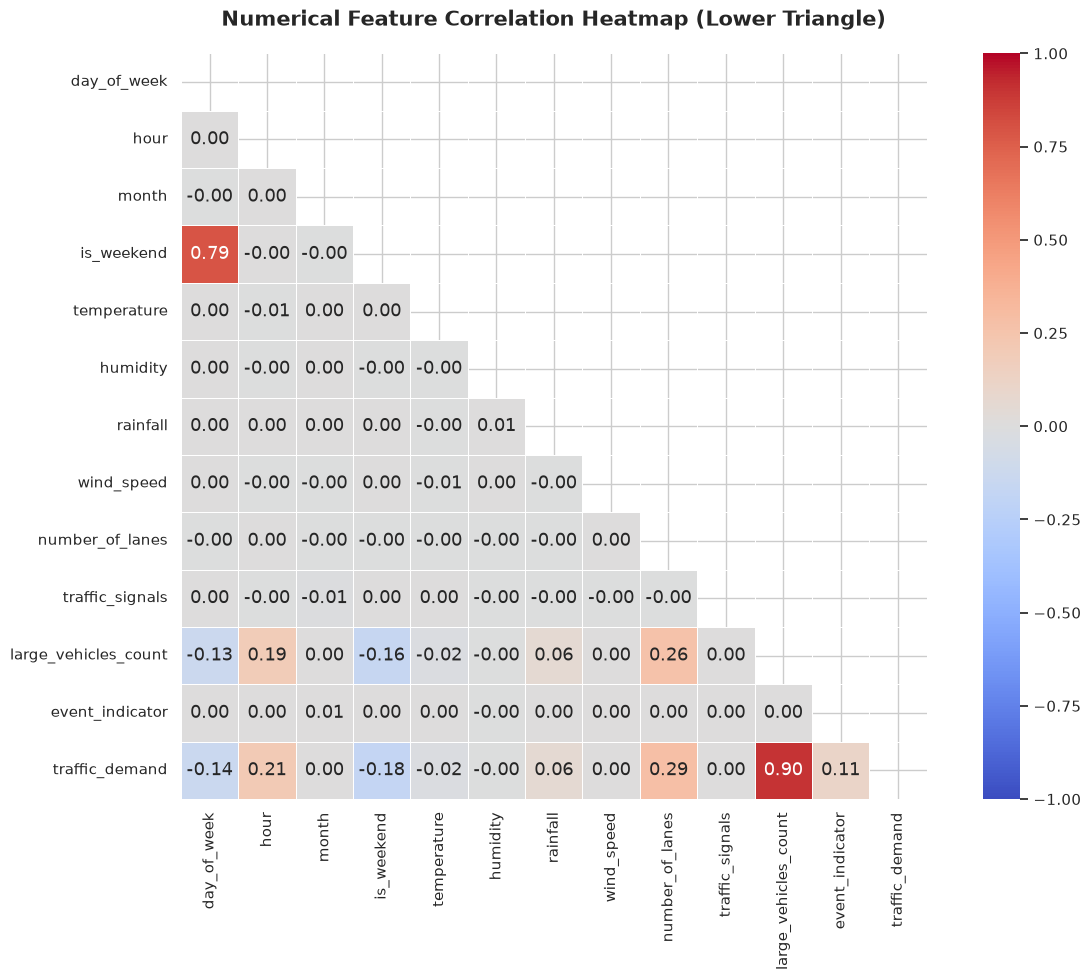


Top correlations with traffic_demand:
large_vehicles_count    0.900654
number_of_lanes         0.287703
hour                    0.209951
is_weekend             -0.178513
day_of_week            -0.140481
event_indicator         0.112801
rainfall                0.061307
temperature            -0.022239
month                   0.003064
wind_speed              0.001607
humidity               -0.000987
traffic_signals         0.000216


In [13]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr = df[numeric_cols].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))   # upper triangle mask

fig, ax = plt.subplots(figsize=(13, 10))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', cbar=True, square=True,
    linewidths=0.5, vmin=-1, vmax=1, ax=ax
)
ax.set_title('Numerical Feature Correlation Heatmap (Lower Triangle)', pad=20)
plt.tight_layout()
plt.show()

# Top correlations with target
target_corr = corr['traffic_demand'].drop('traffic_demand').sort_values(key=abs, ascending=False)
print("\nTop correlations with traffic_demand:")
print(target_corr.to_string())

**Interpretation:**
- **`large_vehicles_count`** shows the **strongest positive correlation** with traffic demand — more trucks/buses = more traffic.
- **`number_of_lanes`** is positively correlated (wider roads carry more vehicles).
- **`hour`** and **`day_of_week`** have moderate correlations, but these are *cyclical* in nature — linear correlation undersells their true importance (hence sine/cosine encoding).
- **`temperature`**, **`humidity`**, and **`wind_speed`** show weak individual correlations, but compound weather features improve predictive power.
- **Multicollinearity** between `hour`, `day_of_week`, and `month` is expected but handled by tree-based models gracefully.

### 5.8 Outlier Analysis

Outliers in the target variable (`traffic_demand`) can distort the loss function and force models to fit extreme values at the expense of typical values. Here we quantify and visualise them before deciding on a treatment strategy.

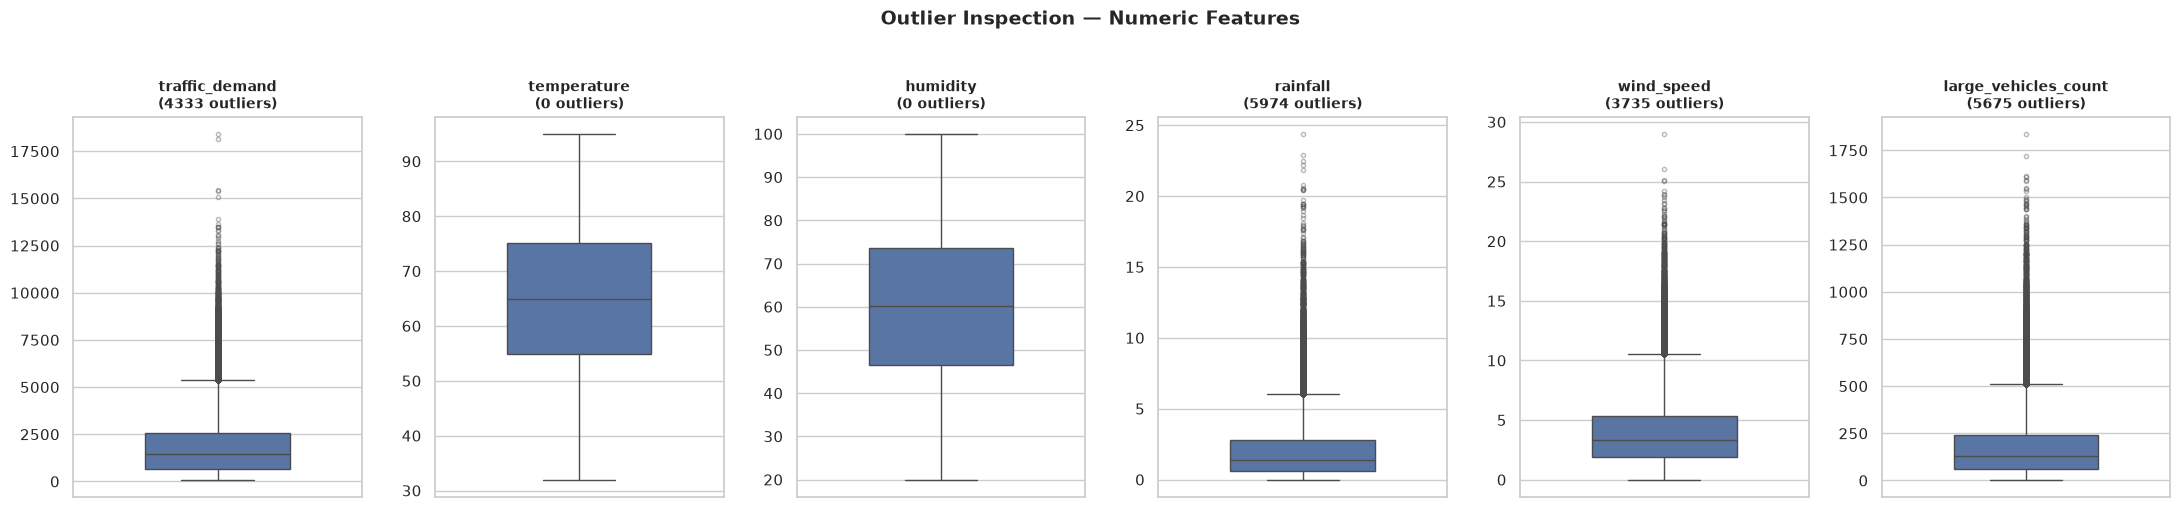

traffic_demand Winsorization bounds: [196, 7217]
  Values clipped below lower bound : 1,188 (0.99%)
  Values clipped above upper bound : 1,200 (1.00%)


In [14]:
numeric_feats = ['traffic_demand', 'temperature', 'humidity', 'rainfall', 
                 'wind_speed', 'large_vehicles_count']

fig, axes = plt.subplots(1, len(numeric_feats), figsize=(22, 5))
for ax, col in zip(axes, numeric_feats):
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    sns.boxplot(y=df[col], color=PRIMARY, ax=ax, width=0.5, flierprops={'marker': 'o', 'markersize': 3, 'alpha': 0.4})
    ax.set_title(f'{col}\n({n_out} outliers)', fontsize=10)
    ax.set_ylabel('')

plt.suptitle('Outlier Inspection — Numeric Features', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Winsorization bounds
p1  = df['traffic_demand'].quantile(0.01)
p99 = df['traffic_demand'].quantile(0.99)
n_lower = (df['traffic_demand'] < p1).sum()
n_upper = (df['traffic_demand'] > p99).sum()
print(f"traffic_demand Winsorization bounds: [{p1:.0f}, {p99:.0f}]")
print(f"  Values clipped below lower bound : {n_lower:,} ({n_lower/len(df)*100:.2f}%)")
print(f"  Values clipped above upper bound : {n_upper:,} ({n_upper/len(df)*100:.2f}%)")

**Why Winsorisation instead of removal?**
- Extreme values may correspond to **real events** (festivals, accidents, infrastructure closures) — simply removing them would discard valid information.
- **Winsorisation (clipping at 1st–99th percentile)** replaces extremes with the boundary values, preserving the observations while limiting their disproportionate influence on the squared-error loss.

### 5.9 Pairplot (Sampled)

A pairplot reveals bivariate relationships and class separation across the most important numeric features.

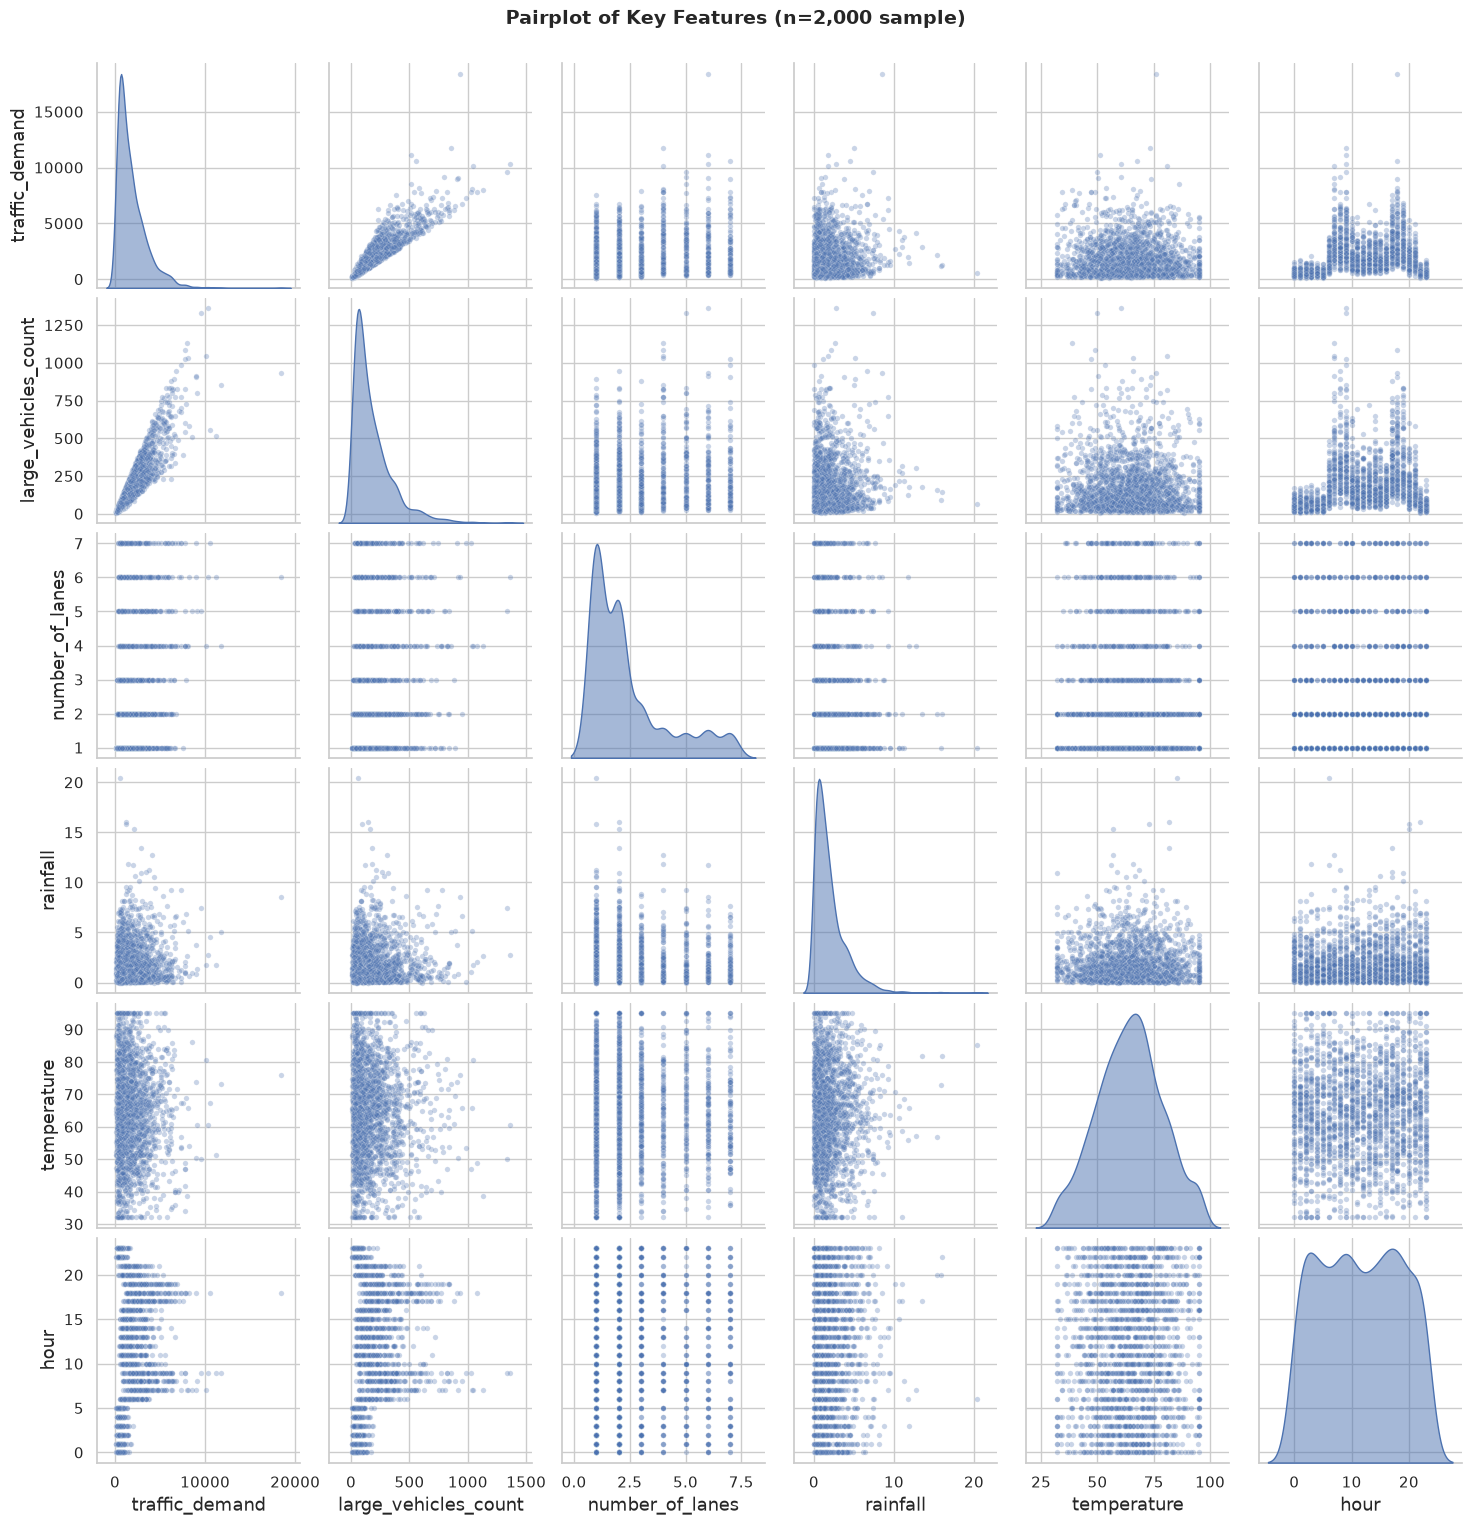

In [15]:
pairplot_cols = ['traffic_demand', 'large_vehicles_count', 'number_of_lanes', 
                 'rainfall', 'temperature', 'hour']
sample_pp = df[pairplot_cols].sample(2000, random_state=42)

g = sns.pairplot(
    sample_pp, diag_kind='kde',
    plot_kws={'alpha': 0.3, 's': 15, 'color': PRIMARY},
    diag_kws={'color': PRIMARY, 'fill': True, 'alpha': 0.5}
)
g.figure.suptitle('Pairplot of Key Features (n=2,000 sample)', y=1.02, fontsize=14, fontweight='bold')
plt.show()

---
## 6. Data Cleaning

Data cleaning is handled by our `preprocess_pipeline` from [`src/preprocessing.py`](../src/preprocessing.py). The pipeline performs:

1. **Deduplication** — drops duplicate rows on `(timestamp, geohash_location)` composite key.
2. **Missing value imputation** — median for numerics, mode for categoricals.
3. **Outlier handling** — Winsorises `traffic_demand` at the 1st and 99th percentiles.
4. **Type enforcement** — parses `timestamp` to `datetime64`.

The pipeline runs *before* any feature engineering to prevent contamination.

In [16]:
import os
os.chdir('..')   # move to project root for pipeline imports

df_clean = preprocess_pipeline(
    file_path='data/raw/smart_city_traffic_data.csv',
    config_path='config/feature_config.yaml'
)

print(f"\n✅ Preprocessing complete.")
print(f"   Raw shape   : {df.shape}")
print(f"   Clean shape : {df_clean.shape}")
print(f"   Rows removed: {df.shape[0] - df_clean.shape[0]}")
print(f"   Target range after Winsorization: [{df_clean['traffic_demand'].min():.0f}, {df_clean['traffic_demand'].max():.0f}]")

2026-07-01 22:11:03,358 [INFO] Successfully loaded configuration from config/feature_config.yaml
2026-07-01 22:11:03,638 [INFO] Successfully loaded data from data/raw/smart_city_traffic_data.csv. Shape: (120000, 19)
2026-07-01 22:11:03,639 [INFO] Data validation passed successfully.
2026-07-01 22:11:03,680 [INFO] Outlier boundaries for traffic_demand: [196.0, 7217.009999999995]. Winsorizing 1188 values below lower bound and 1200 values above upper bound.
2026-07-01 22:11:03,683 [INFO] Preprocessing completed successfully. Preprocessed shape: (120000, 19)



✅ Preprocessing complete.
   Raw shape   : (120000, 19)
   Clean shape : (120000, 19)
   Rows removed: 0
   Target range after Winsorization: [196, 7217]
